# 03 — Exploration

**Purpose.** Exploratory analysis to validate that the integrated
tables support the rationale memo's central analytical claim, and to
identify the specific chart that will go into each of the eight visual
components in Phase 4. This is the feasibility-check layer: chart
prototypes and a handoff map to Phase 4 follow in subsequent sections,
not in this section.

**Inputs.** The two silver-layer parquets under
`../data/processed/integrated/` (`models_enriched.parquet`,
`regions_geographic.parquet`), plus the bronze IM3 atlas and
Ember US-states parquets under `../data/processed/im3/` and
`../data/processed/ember/` for the all-layers facility counts and the
state-level grid intensity figures. The bronze Aqueduct province
parquet is also loaded — `regions_geographic` only covers states where
an AWS or Azure region is sited, and the triangulation needs Washington
state, which has no such region.

**Outputs.** None written to disk. The notebook's outputs are its
rendered cells. The chart-prototype map at the end of this notebook is
Phase 4's handoff artefact and is read in chat, not from a file.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Data load

Load the silver-layer integrated tables plus three bronze parquets
the triangulation requires at finer grain than the silver layer
carries.

In [7]:
PROCESSED = Path("../data/processed")
INTEGRATED = PROCESSED / "integrated"

models_enriched = pd.read_parquet(INTEGRATED / "models_enriched.parquet")
regions_geographic = pd.read_parquet(INTEGRATED / "regions_geographic.parquet")
im3_atlas = pd.read_parquet(
    PROCESSED / "im3" / "im3_open_source_data_center_atlas_v2026_02_09.parquet"
)
ember_us_states = pd.read_parquet(
    PROCESSED / "ember" / "ember_us_states.parquet"
)
aqueduct_province = pd.read_parquet(
    PROCESSED / "aqueduct" / "Aqueduct40_province_baseline.parquet"
)

print(f"models_enriched:    {models_enriched.shape}")
print(f"regions_geographic: {regions_geographic.shape}")
print(f"im3_atlas:          {im3_atlas.shape}")
print(f"ember_us_states:    {ember_us_states.shape}")
print(f"aqueduct_province:  {aqueduct_province.shape}")

models_enriched:    (194, 105)
regions_geographic: (37, 12)
im3_atlas:          (1479, 13)
ember_us_states:    (73442, 13)
aqueduct_province:  (42771, 12)


## Triangulation

The dataset rationale memo's Integration paragraph states: *Virginia
hosts 319 of the 1,479 US data centres in the IM3 Atlas, has a 2025
grid carbon intensity of 327 gCO₂/kWh in Ember, and a baseline water
stress score of 2.56 in Aqueduct — versus Washington's 82 facilities,
124 gCO₂/kWh intensity, and 1.20 water stress score.* This section
reproduces those six numbers from the loaded tables, plus the same
three numbers for Arizona (the implementation plan's third leg, which
the memo does not publish specific figures for).

### Facility counts — IM3 atlas, all layers

The memo's facility counts are all-layers (campus + building + point);
the silver-layer `regions_geographic` carries campus-only aggregates,
so this subsection reads from the bronze IM3 parquet.

In [8]:
states_of_interest = ["Virginia", "Washington", "Arizona"]
facility_counts = (
    im3_atlas[im3_atlas["state"].isin(states_of_interest)]
    .groupby("state")
    .size()
    .reindex(states_of_interest)
)

print(f"Total IM3 rows (all layers, all states): {len(im3_atlas)}")
print("\nFacility counts (all layers):")
print(facility_counts.to_string())

Total IM3 rows (all layers, all states): 1479

Facility counts (all layers):
state
Virginia      319
Washington     82
Arizona        65


### Grid carbon intensity — Ember US-states, latest year

Filter to `Variable == 'CO2 intensity'` (the canonical filter applied
in the integration notebook) and pick the most recent year available
per state.

In [9]:
ember_co2 = ember_us_states[ember_us_states["Variable"] == "CO2 intensity"]
ember_latest = (
    ember_co2.sort_values("Year")
    .drop_duplicates("State", keep="last")
    .set_index("State")
)

for state in states_of_interest:
    row = ember_latest.loc[state]
    print(f"{state}: {row['Value']:.2f} {row['Unit']} ({int(row['Year'])})")

Virginia: 327.17 gCO2/kWh (2025)
Washington: 124.36 gCO2/kWh (2025)
Arizona: 282.98 gCO2/kWh (2025)


### Water stress — Aqueduct province, `bws` indicator at `Tot` weighting

`regions_geographic` only carries water stress for states where an AWS
or Azure region is sited (Virginia and Arizona qualify; Washington
does not — the nearest AWS region, US West (Oregon), is in Oregon).
Reading from the bronze Aqueduct province parquet gives all three
states uniformly at the same grain.

In [10]:
aq_us = aqueduct_province[
    (aqueduct_province["gid_0"] == "USA")
    & (aqueduct_province["indicator_name"] == "bws")
    & (aqueduct_province["weight"] == "Tot")
].set_index("name_1")

for state in states_of_interest:
    print(f"{state}: {aq_us.loc[state, 'score']:.4f}")

Virginia: 2.5624
Washington: 1.2032
Arizona: 4.3921


### Triangulation summary

**Reproduced as published.** All six memo-cited numbers reproduce from
the loaded tables. Virginia: 319 facilities, 327.17 gCO₂/kWh (2025),
water stress 2.5624. Washington: 82 facilities, 124.36 gCO₂/kWh
(2025), water stress 1.2032. The IM3 total of 1,479 also reproduces.
Memo figures are rounded; data values are precise to the source-file
precision.

**Discrepancies.** None at the level the memo reports. Memo rounds
327.17 → 327, 124.36 → 124, 2.5624 → 2.56, 1.2032 → 1.20; all
rounding is consistent with what the memo claims.

**Arizona, reported (no comparison gate).** 65 facilities, 282.98
gCO₂/kWh (2025), water stress 4.3921. The water-stress score is the
highest of the three states — Arizona is the canonical "hot grid in a
water-stressed region" case the third triangulation leg surfaces.

## Component 1 — Prompt-pipeline animation (data-availability check)

Component 1 is the D3 animation, not a static chart. The prototype
tests that `models_enriched` carries the per-(model, query length)
energy / water / carbon values for the six showcase models the brief
names, and produces an in-memory dict mirroring the JSON shape Phase 4
will read.

Five of the six brief names do not land verbatim in the file. The
renames applied here are auditable in the closing notes.

In [11]:
# Brief name → actual Model in models_enriched. The five disambiguators
# (case, parens, host suffix) are explained in the closing notes.
showcase = {
    "GPT-4o": "GPT-4o (Aug)",
    "Claude 3.7 Sonnet": "Claude 3.7 Sonnet",
    "GPT-5 minimal": "GPT-5 (minimal)",
    "GPT-5 reasoning": "GPT-5 (high)",
    "LLaMA 3.1 8B": "Llama 3.1 8B",
    "DeepSeek-R1": "DeepSeek R1 (DeepSeek) [128k]",
}

# Jegham's Query Length is integer token counts; map to the brief's
# short / medium / long labels for the animation's tier axis.
tier_label = {300: "short", 1000: "medium", 1500: "long"}

rows = []
for brief_name, actual in showcase.items():
    sub = models_enriched[models_enriched["Model"] == actual]
    for ql in [300, 1000, 1500]:
        r = sub[sub["Query Length"] == ql]
        if len(r):
            r = r.iloc[0]
            rows.append(
                {
                    "brief_name": brief_name,
                    "tier": tier_label[ql],
                    "wh": round(r["Mean Combined Energy (Wh)"], 4),
                    "ml": round(r["Mean Combined Water (Site & Source, mL)"], 4),
                    "gco2": round(r["Mean Combined Carbon (gCO2e)"], 4),
                }
            )
        else:
            rows.append(
                {
                    "brief_name": brief_name,
                    "tier": tier_label[ql],
                    "wh": None,
                    "ml": None,
                    "gco2": None,
                }
            )

availability = pd.DataFrame(rows)
print(availability.to_string(index=False))

       brief_name   tier      wh       ml    gco2
           GPT-4o  short  0.4187   1.9333  0.1423
           GPT-4o medium  1.3541   6.2532  0.4604
           GPT-4o   long  2.2215  10.2584  0.7553
Claude 3.7 Sonnet  short  0.9503   5.0155  0.2851
Claude 3.7 Sonnet medium  2.9886  15.7736  0.8966
Claude 3.7 Sonnet   long  5.6714  29.9329  1.7014
    GPT-5 minimal  short  0.7894   3.6451  0.2684
    GPT-5 minimal medium  2.1027   9.7101  0.7149
    GPT-5 minimal   long  6.3831  29.4764  2.1703
  GPT-5 reasoning  short 13.6825  63.1837  4.6520
  GPT-5 reasoning medium 16.4516  75.9709  5.5935
  GPT-5 reasoning   long 25.5958 118.1977  8.7026
     LLaMA 3.1 8B  short  0.0517   0.2727  0.0155
     LLaMA 3.1 8B medium  0.1723   0.9096  0.0517
     LLaMA 3.1 8B   long  0.4430   2.3383  0.1329
      DeepSeek-R1  short 19.2507 134.0018 11.5504
      DeepSeek-R1 medium 24.5958 171.2082 14.7575
      DeepSeek-R1   long 29.0782 202.4102 17.4469


In [12]:
# In-memory dict mirroring the JSON shape Phase 4 will consume.
# Not written to disk — Phase 4 owns serialisation.
import pprint

prompt_pipeline_data = {}
for brief_name, actual in showcase.items():
    prompt_pipeline_data[brief_name] = {}
    for ql in [300, 1000, 1500]:
        r = models_enriched[
            (models_enriched["Model"] == actual)
            & (models_enriched["Query Length"] == ql)
        ]
        if len(r):
            row = r.iloc[0]
            prompt_pipeline_data[brief_name][tier_label[ql]] = {
                "wh": round(float(row["Mean Combined Energy (Wh)"]), 4),
                "ml": round(
                    float(row["Mean Combined Water (Site & Source, mL)"]), 4
                ),
                "gco2": round(float(row["Mean Combined Carbon (gCO2e)"]), 4),
            }

pprint.pprint(prompt_pipeline_data, sort_dicts=False, width=88)

{'GPT-4o': {'short': {'wh': 0.4187, 'ml': 1.9333, 'gco2': 0.1423},
            'medium': {'wh': 1.3541, 'ml': 6.2532, 'gco2': 0.4604},
            'long': {'wh': 2.2215, 'ml': 10.2584, 'gco2': 0.7553}},
 'Claude 3.7 Sonnet': {'short': {'wh': 0.9503, 'ml': 5.0155, 'gco2': 0.2851},
                       'medium': {'wh': 2.9886, 'ml': 15.7736, 'gco2': 0.8966},
                       'long': {'wh': 5.6714, 'ml': 29.9329, 'gco2': 1.7014}},
 'GPT-5 minimal': {'short': {'wh': 0.7894, 'ml': 3.6451, 'gco2': 0.2684},
                   'medium': {'wh': 2.1027, 'ml': 9.7101, 'gco2': 0.7149},
                   'long': {'wh': 6.3831, 'ml': 29.4764, 'gco2': 2.1703}},
 'GPT-5 reasoning': {'short': {'wh': 13.6825, 'ml': 63.1837, 'gco2': 4.652},
                     'medium': {'wh': 16.4516, 'ml': 75.9709, 'gco2': 5.5935},
                     'long': {'wh': 25.5958, 'ml': 118.1977, 'gco2': 8.7026}},
 'LLaMA 3.1 8B': {'short': {'wh': 0.0517, 'ml': 0.2727, 'gco2': 0.0155},
                  'medium': 

In [13]:
# DeepSeek R1 ships in two hostings. The brief-faithful pick is the
# vendor-host (parallel to Llama-on-vendor rather than -on-hyperscaler).
# This cell quantifies how different the two hostings actually are at
# long-query length — the magnitude is in the closing notes.
ds = models_enriched[
    models_enriched["Model"].isin(
        ["DeepSeek R1 (Azure)", "DeepSeek R1 (DeepSeek) [128k]"]
    )
    & (models_enriched["Query Length"] == 1500)
][
    [
        "Model",
        "Host",
        "PUE",
        "CIF",
        "Mean Combined Energy (Wh)",
        "Mean Combined Carbon (gCO2e)",
        "Mean Combined Water (Site & Source, mL)",
    ]
]
print(ds.to_string(index=False))

                        Model     Host  PUE  CIF  Mean Combined Energy (Wh)  Mean Combined Carbon (gCO2e)  Mean Combined Water (Site & Source, mL)
DeepSeek R1 (DeepSeek) [128k] DeepSeek 1.27 0.60                  29.078236                     17.446941                               202.410164
          DeepSeek R1 (Azure)    Azure 1.12 0.34                   7.410171                      2.519458                                34.219109


**Notes.**

*Renames applied to the brief's six showcase names:* `GPT-4o` →
`GPT-4o (Aug)` (Jegham snapshots the Aug-2024 variant); `GPT-5
minimal` → `GPT-5 (minimal)`; `GPT-5 reasoning` → `GPT-5 (high)`;
`LLaMA 3.1 8B` → `Llama 3.1 8B`; `DeepSeek-R1` → `DeepSeek R1
(DeepSeek) [128k]`. `Claude 3.7 Sonnet` lands verbatim.

*GPT-5 reasoning effort is a four-tier axis in the file:* `(minimal)`,
`(low)`, `(medium)`, `(high)`. The brief's `GPT-5 reasoning` slot most
naturally pairs with the highest-effort tier — the slot's analytical
purpose is to show what reasoning costs at the upper bound, against
`GPT-5 minimal` at the lower bound. `(high)` is the brief-faithful
pick on that framing; `(medium)` would have been a defensible
alternative if the brief had spread three GPT-5 tiers across the
showcase.

*DeepSeek R1 hosting matters analytically.* At long-query length, the
vendor-hosted variant draws roughly 4× the energy and 7× the carbon
of the Azure-hosted variant — driven by DeepSeek's higher PUE (1.27
vs 1.12) and substantially higher CIF (0.60 vs 0.34, the latter
reflecting Azure's lower-carbon grid mix). The vendor-host pick
matches the brief's intent of showing models on their canonical
infrastructure rather than re-routed through a hyperscaler. This is a
live design tension Phase 4 should foreground in the animation's
model-selector copy.

All six showcase models have data populated for all three query
lengths. No gaps; no Phase 4 follow-ups required from this prototype.

## Component 2 — Model comparison panel (energy vs capability scatter)

Tests whether the brief's analytical pattern — frontier reasoning
models cluster top-right (high training compute, high per-query
energy), efficient open-weight models bottom-left — actually shows up
in the matched-Epoch subset.

models with FLOP populated at long-query: 15
organizations represented: 5
Organization
Meta AI       6
OpenAI        4
Anthropic     2
Mistral AI    2
xAI           1


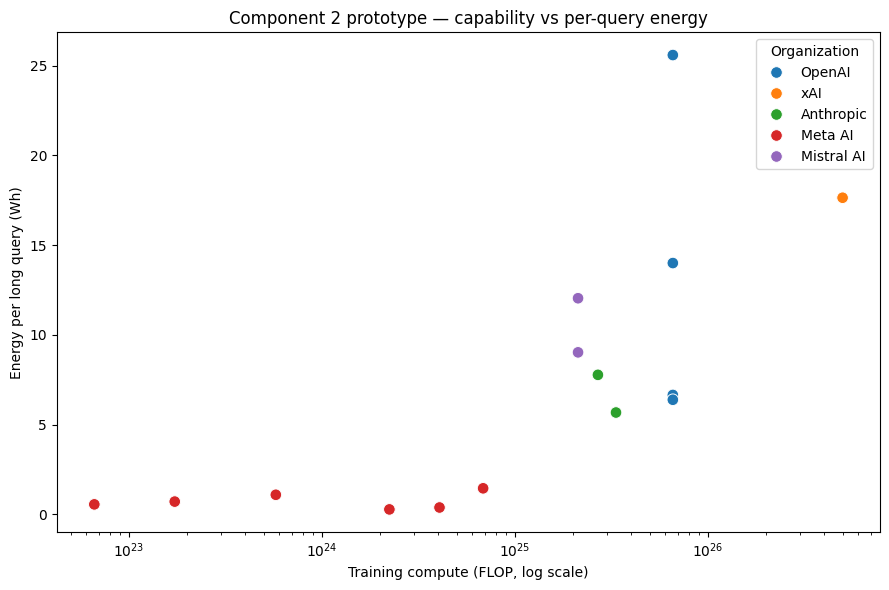

In [14]:
# X-axis pick: Training compute (FLOP) has 45/134 matched-row population
# vs Parameters at 35/134. FLOP is the better-populated training-side
# axis and the natural log-scale fit for capability proxy.
long_unique = models_enriched[
    models_enriched["Query Length"] == 1500
].drop_duplicates("Model")
scatter_pool = long_unique[
    long_unique["Training compute (FLOP)"].notna()
].copy()
print(f"models with FLOP populated at long-query: {len(scatter_pool)}")
print(f"organizations represented: {scatter_pool['Organization'].nunique()}")
print(scatter_pool["Organization"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=scatter_pool,
    x="Training compute (FLOP)",
    y="Mean Combined Energy (Wh)",
    hue="Organization",
    s=70,
    ax=ax,
)
ax.set_xscale("log")
ax.set_xlabel("Training compute (FLOP, log scale)")
ax.set_ylabel("Energy per long query (Wh)")
ax.set_title("Component 2 prototype — capability vs per-query energy")
plt.tight_layout()
plt.show()

**Notes.** The scatter renders cleanly. The 21 unmatched-Epoch models
are absent (no FLOP value) — Claude 4 Opus / Sonnet, GPT-4 / GPT-4
Turbo, Gemini 2.5 Pro variants, Grok 3 Fast and mini variants, the
Llama 3 / 3.1 variants, Mistral Small (Feb), DeepSeek R1 / V3 hosted
variants. So is the additional matched-but-no-FLOP block (~89 rows at
long-query). The 15 plottable models include the GPT-5 family at
6.6e25 FLOP, Grok 4 at 5e26 (the upper-right outlier), Claude 3.5 /
3.7 Sonnet around 3e25, and the Llama 3.2 1B / 3B / 11B cluster at
1e23–1e24. The brief's analytical pattern holds qualitatively but the
sample is thin enough that Phase 4 should consider whether to plot
all 66 models with parametric proxies (e.g. Parameters where FLOP
missing) or limit honestly to the 15-point matched subset.

## Component 3 — Geographic impact map (parallel prototypes)

Two parallel prototypes covering the unresolved US-vs-global design
question. Cut 1 keys off bronze IM3 (US-only, facility-level). Cut 2
keys off `regions_geographic` (global, cloud-region-level).

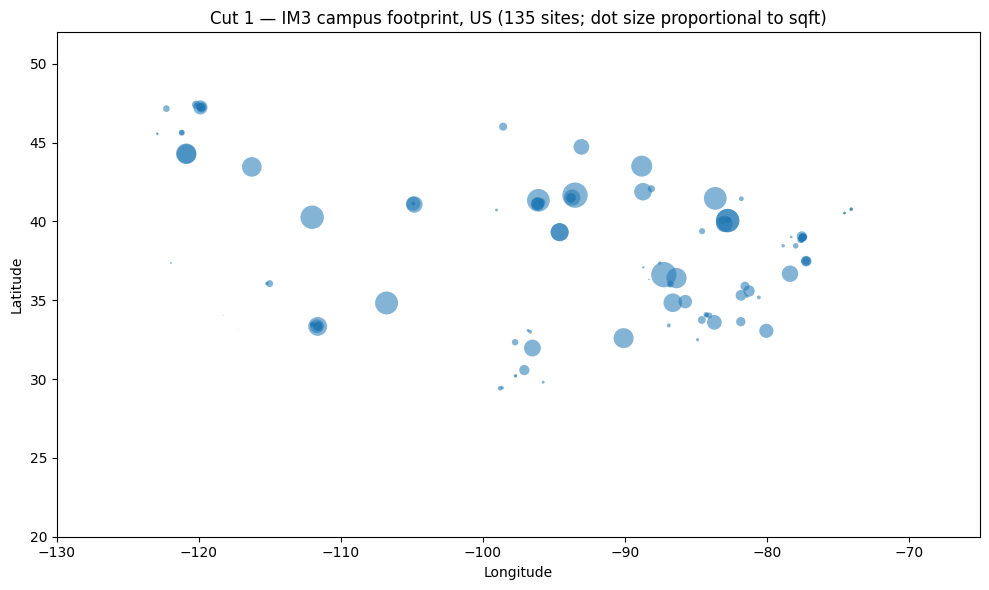

In [15]:
# Cut 1 — US IM3 campus dots. geopandas is not installed and the prompt
# specifies no new dependencies in this phase, so this falls back to a
# lat/lon scatter without state polygons. The fallback is documented
# in the closing notes.
campus_us = im3_atlas[
    (im3_atlas["type"] == "campus") & im3_atlas["sqft"].notna()
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    campus_us["lon"],
    campus_us["lat"],
    s=campus_us["sqft"] / 80000,
    alpha=0.55,
    edgecolor="none",
)
ax.set_xlim(-130, -65)
ax.set_ylim(20, 52)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Cut 1 — IM3 campus footprint, US ({len(campus_us)} sites; dot size proportional to sqft)"
)
plt.tight_layout()
plt.show()

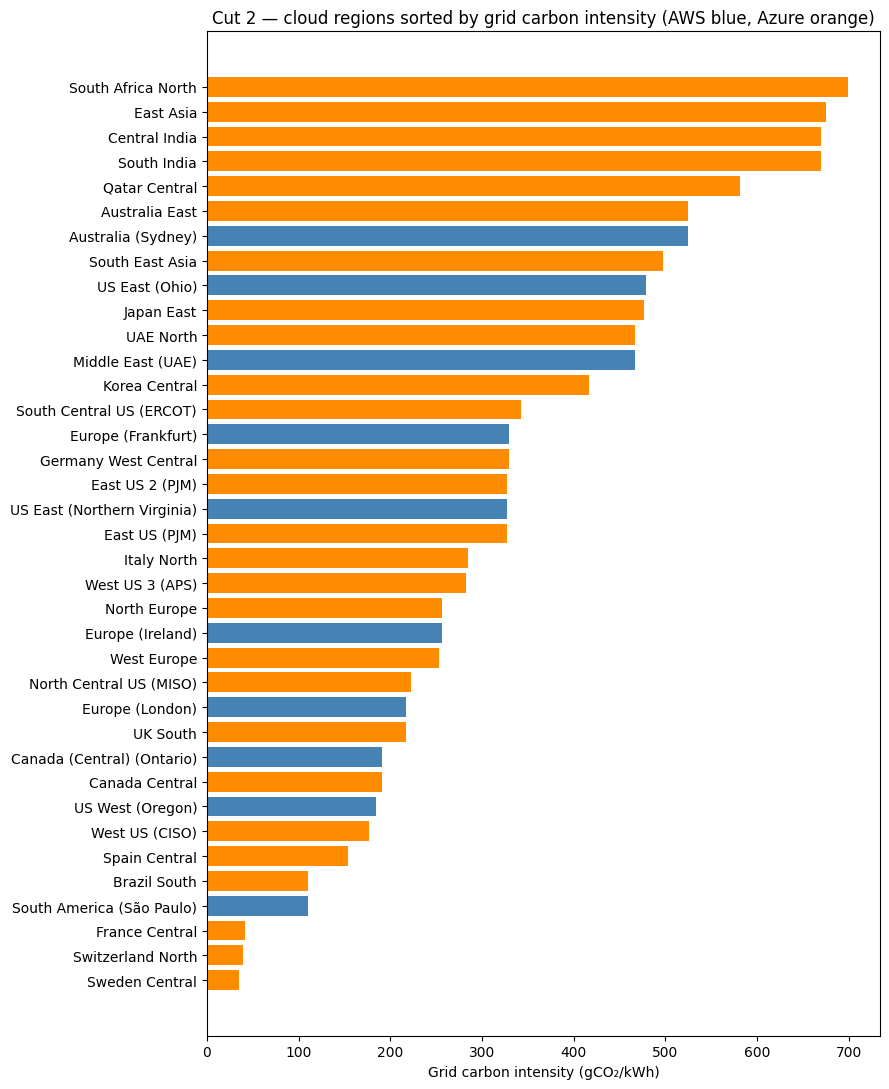

In [16]:
# Cut 2 — global cloud regions. regions_geographic does not carry
# lat/lon (the multiplier files publish region names only); the
# prototype falls back to a horizontal bar chart sorted by grid carbon
# intensity, which surfaces the same analytical content (which regions
# are clean, which are dirty) without inventing a coordinate mapping.
rg_sorted = regions_geographic.sort_values(
    "grid_carbon_intensity_gco2_kwh"
).reset_index(drop=True)
colors = ["steelblue" if p == "AWS" else "darkorange" for p in rg_sorted["provider"]]

fig, ax = plt.subplots(figsize=(9, 11))
ax.barh(rg_sorted["region_name"], rg_sorted["grid_carbon_intensity_gco2_kwh"], color=colors)
ax.set_xlabel("Grid carbon intensity (gCO₂/kWh)")
ax.set_title("Cut 2 — cloud regions sorted by grid carbon intensity (AWS blue, Azure orange)")
plt.tight_layout()
plt.show()

**Design question, surfaced.** The brief's Section 5 says "US data
centre map" but Section 4.5 says the map shows "distribution of cloud
regions used by a model's provider, not 'where your query went.'"
These two framings point at different prototypes.

Cut 1 (US IM3) supports the Section-5 framing: the actual physical
data-centre footprint, all hyperscalers and colocation providers
lumped together at the campus layer. It surfaces concentration
(Virginia's 31 campuses dominate the East Coast) and is the right
answer if the component is about "where data centres are" as
infrastructure.

Cut 2 (cloud-region) supports the Section-4.5 framing: the regions a
frontier model's provider actually has on its menu, with each
region's grid carbon and water-stress context attached. It surfaces
the regions Phase 4's per-query stories are actually keyed to (the
Jegham `Host` column joins to AWS / Azure rows here). Cut 2's
fallback to a sorted bar instead of a map is a Phase-4 dependency
decision; if the production version wants a real map, geopandas plus
a region-name → lat/lon mapping table become Phase 4 prerequisites.
Neither cut should be assumed; Phase 4 picks one explicitly.

*geopandas note.* Not installed in the current environment; this
prompt does not add it to `requirements.txt`. Cut 1 falls back to a
polygon-free lat/lon scatter.

## Component 4 — Training compute trajectory (line chart)

Tests whether the matched-Epoch subset has enough FLOP-populated
models to render a meaningful trajectory, and whether the analytical
pattern (compute scaling roughly exponentially with publication date)
shows up.

unique models in trajectory pool: 15


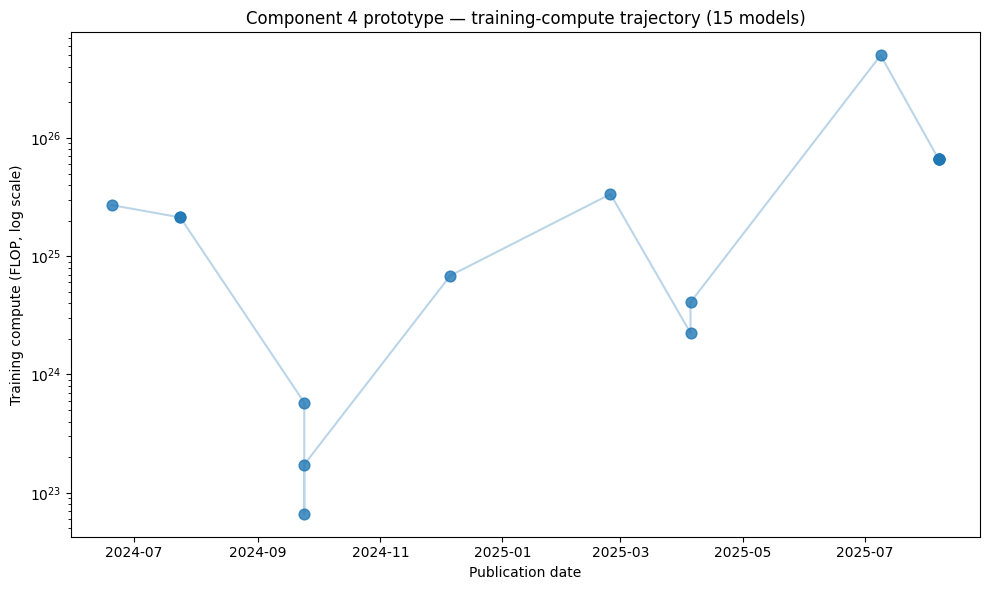

In [17]:
trajectory = (
    models_enriched[
        models_enriched["Training compute (FLOP)"].notna()
        & models_enriched["Publication date"].notna()
    ]
    .drop_duplicates("Model")
    .copy()
)
trajectory["Publication date"] = pd.to_datetime(trajectory["Publication date"])
trajectory = trajectory.sort_values("Publication date")
print(f"unique models in trajectory pool: {len(trajectory)}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    trajectory["Publication date"], trajectory["Training compute (FLOP)"],
    s=60, alpha=0.8
)
ax.plot(
    trajectory["Publication date"], trajectory["Training compute (FLOP)"],
    alpha=0.3,
)
ax.set_yscale("log")
ax.set_xlabel("Publication date")
ax.set_ylabel("Training compute (FLOP, log scale)")
ax.set_title(
    f"Component 4 prototype — training-compute trajectory ({len(trajectory)} models)"
)
plt.tight_layout()
plt.show()

**Notes.** 15 unique models populate the trajectory pool. Several
share dates and FLOP values (the four GPT-5 reasoning-effort variants
all sit at the same coordinate; `Mistral Large 2 (Azure)` and `(AWS)`
overlap), so the rendered trajectory has roughly 12 visually distinct
points. The pattern holds: late-2024 frontier (Claude 3.5 Sonnet,
Mistral Large 2) at ~2e25 FLOP; small Llama 3.2 variants at
1e23–1e24; mid-2025 frontier (GPT-5, Grok 4) at 6.6e25–5e26 — about
half a decade of compute scaling visible across roughly fourteen
months of publication dates. Phase 4's production line chart should
annotate the GPT-5 cluster and Grok 4 explicitly; the cluster on a
single date risks looking like a single point at default scatter
sizes.

## Component 5 — Aggregate scaling (per-query × volume)

Tests whether Jegham's pre-computed billion-prompt aggregates and
everyday-equivalence columns are present in `models_enriched` and
render cleanly for one representative model. Phase 4's production
version is model-selectable; this prototype uses GPT-4o (Aug) at
long-query length for consistency with Components 1 and 8.

Per-query (GPT-4o (Aug), long):
  energy: 2.2215 Wh
  water:  10.2584 mL
  carbon: 0.7553 gCO₂e

At scale (Jegham pre-computed):
      scale    energy_MWh     water_kL  carbon_tCO2e
  1 Billion   2221.453787 1.025836e+04    755.294288
 50 Billion 111072.689373 5.129178e+05  37764.714387
100 Billion  22214.537875 1.025836e+06  75529.428774

Everyday equivalences (1B prompts):
  Household Energy Equiv. – 1B Prompts (MWh): 2028.724920051523
  Olympic Swimming Pools Equiv. – 1B Prompts (kL): 4.103342495973068
  Atlantic Flight Equiv. – 1B Prompts (TonsCO2e): 12.5882381289197


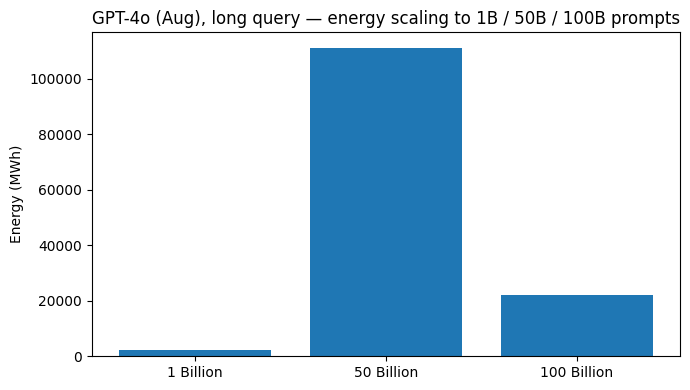

In [18]:
target = models_enriched[
    (models_enriched["Model"] == "GPT-4o (Aug)")
    & (models_enriched["Query Length"] == 1500)
].iloc[0]

print("Per-query (GPT-4o (Aug), long):")
print(f"  energy: {target['Mean Combined Energy (Wh)']:.4f} Wh")
print(f"  water:  {target['Mean Combined Water (Site & Source, mL)']:.4f} mL")
print(f"  carbon: {target['Mean Combined Carbon (gCO2e)']:.4f} gCO₂e")

scales = ["1 Billion", "50 Billion", "100 Billion"]
rows = []
for s in scales:
    rows.append(
        {
            "scale": s,
            "energy_MWh": target[f"Energy Consumption of {s} Prompts (MWh)"],
            "water_kL": target[f"Water Consumption of {s} Prompts (Kiloliter)"],
            "carbon_tCO2e": target[f"Carbon Emissions of {s} Prompts (TonsCO2e)"],
        }
    )
scale_table = pd.DataFrame(rows)
print("\nAt scale (Jegham pre-computed):")
print(scale_table.to_string(index=False))

# Check the everyday-equivalence columns are also populated.
equiv_cols = [
    "Household Energy Equiv. – 1B Prompts (MWh)",
    "Olympic Swimming Pools Equiv. – 1B Prompts (kL)",
    "Atlantic Flight Equiv. – 1B Prompts (TonsCO2e)",
]
print("\nEveryday equivalences (1B prompts):")
for c in equiv_cols:
    print(f"  {c}: {target[c]}")

# Quick visual: energy scaling as bars.
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(scale_table["scale"], scale_table["energy_MWh"])
ax.set_ylabel("Energy (MWh)")
ax.set_title("GPT-4o (Aug), long query — energy scaling to 1B / 50B / 100B prompts")
plt.tight_layout()
plt.show()

**Notes.** Jegham's pre-computed scale aggregates and everyday
equivalences are present in `models_enriched` (27 such columns).
Phase 4 does not have to derive them — read directly. The model
picked here is GPT-4o (Aug); the production version will be
model-selectable from the 66-model spine, and the scale axis is
1B / 50B / 100B native to Jegham. Phase 4 should pick whichever of
the three everyday-equivalence framings (households, swimming pools,
transatlantic flights) lands hardest in the brief's audience
register; the data carries all three.

## Component 6 — Efficiency vs demand small multiples

Tests whether per-query energy varies meaningfully across short /
medium / long for a representative spread of models, and whether a
small-multiples grid renders the within-model curve clearly.

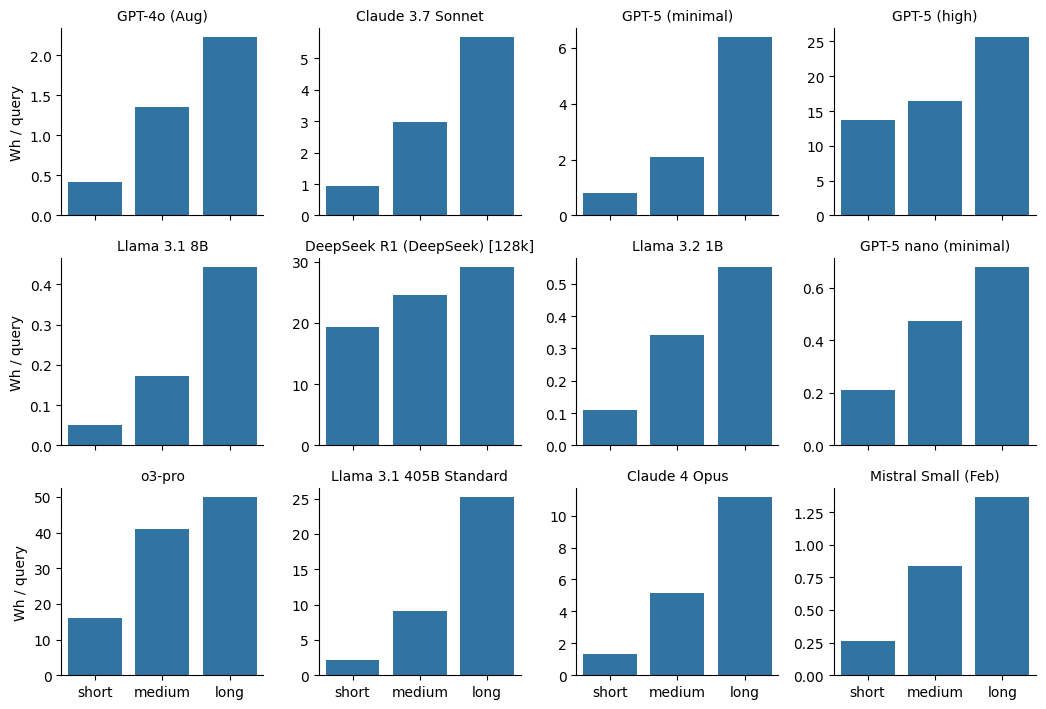

In [19]:
# 12 models spanning the energy range: the six Component-1 showcase
# picks plus six others spanning small-Llama and large reasoning
# tiers. All have full short / medium / long coverage.
selected = [
    "GPT-4o (Aug)",
    "Claude 3.7 Sonnet",
    "GPT-5 (minimal)",
    "GPT-5 (high)",
    "Llama 3.1 8B",
    "DeepSeek R1 (DeepSeek) [128k]",
    "Llama 3.2 1B",
    "GPT-5 nano (minimal)",
    "o3-pro",
    "Llama 3.1 405B Standard",
    "Claude 4 Opus",
    "Mistral Small (Feb)",
]

small_mult = models_enriched[models_enriched["Model"].isin(selected)].copy()
small_mult["tier"] = small_mult["Query Length"].map(tier_label)
small_mult["tier"] = pd.Categorical(
    small_mult["tier"], categories=["short", "medium", "long"], ordered=True
)

g = sns.FacetGrid(
    small_mult,
    col="Model",
    col_wrap=4,
    sharey=False,
    height=2.4,
    aspect=1.1,
    col_order=selected,
)
g.map_dataframe(
    sns.barplot,
    x="tier",
    y="Mean Combined Energy (Wh)",
    order=["short", "medium", "long"],
)
g.set_titles("{col_name}")
g.set_axis_labels("", "Wh / query")
plt.tight_layout()
plt.show()

**Notes.** The 12 selected models span roughly three orders of
magnitude in long-query energy — Llama 3.2 1B at the bottom, o3-pro
at the top (~50 Wh long-query). The within-model short → long curve
is monotonic for every selected model and steepest for reasoning
variants (GPT-5 high, o3-pro, DeepSeek R1). Per-panel y-axis (free
scale) is the right choice for surfacing the within-model story; a
shared y-axis would compress the small models into invisible bars
next to the reasoning frontier. Phase 4's production version should
consider whether to render all 66 models on a denser grid (cardinality
is supportable) or stay at this 12-model curated set for narrative
clarity.

## Component 7 — White-hat / black-hat static pair (data check)

Confirms the integrated tables support both framings. White-hat: the
spread between efficient and frontier models tells an "efficiency is
winning" story. Black-hat: the worst-case combination of high-energy
model × longest query × most water-stressed region is computable.

In [20]:
# White-hat — distribution of long-query energy across all 66 models.
long_unique = models_enriched[
    models_enriched["Query Length"] == 1500
].drop_duplicates("Model")
print("White-hat: long-query energy (Wh) distribution across 66 models")
print(long_unique["Mean Combined Energy (Wh)"].describe().round(3).to_string())
print("\nMost-efficient five (lowest Wh):")
print(
    long_unique.nsmallest(5, "Mean Combined Energy (Wh)")[
        ["Model", "Mean Combined Energy (Wh)"]
    ].to_string(index=False)
)
print("\nMost-energy-intensive five:")
print(
    long_unique.nlargest(5, "Mean Combined Energy (Wh)")[
        ["Model", "Mean Combined Energy (Wh)"]
    ].to_string(index=False)
)

# Black-hat — worst combination.
worst_model_row = long_unique.nlargest(1, "Mean Combined Energy (Wh)").iloc[0]
worst_region_row = regions_geographic.nlargest(1, "water_stress_score").iloc[0]
print("\nBlack-hat worst-case combination:")
print(
    f"  Model:  {worst_model_row['Model']!r} long query — "
    f"{worst_model_row['Mean Combined Energy (Wh)']:.2f} Wh, "
    f"{worst_model_row['Mean Combined Carbon (gCO2e)']:.2f} gCO₂e, "
    f"{worst_model_row['Mean Combined Water (Site & Source, mL)']:.2f} mL"
)
print(
    f"  Region: {worst_region_row['region_name']!r} "
    f"({worst_region_row['provider']}, iso3={worst_region_row['iso3']}) — "
    f"water stress {worst_region_row['water_stress_score']:.2f}, "
    f"grid {worst_region_row['grid_carbon_intensity_gco2_kwh']:.0f} gCO₂/kWh"
)

# Arizona reference, since the triangulation flagged it as the US worst case.
az_row = regions_geographic[regions_geographic["state_abb"] == "AZ"].iloc[0]
print(
    f"\n  US-only reference (Arizona): water stress "
    f"{az_row['water_stress_score']:.2f}, "
    f"grid {az_row['grid_carbon_intensity_gco2_kwh']:.0f} gCO₂/kWh"
)

White-hat: long-query energy (Wh) distribution across 66 models
count    62.000
mean      7.517
std       8.407
min       0.271
25%       2.389
50%       5.435
75%       9.005
max      49.932

Most-efficient five (lowest Wh):
               Model  Mean Combined Energy (Wh)
    Llama 4 Maverick                   0.271434
       Llama 4 Scout                   0.378055
        Llama 3.1 8B                   0.443045
        Llama 3.2 1B                   0.551639
GPT-5 nano (minimal)                   0.678770

Most-energy-intensive five:
                        Model  Mean Combined Energy (Wh)
                       o3-pro                  49.932312
DeepSeek R1 (DeepSeek) [128k]                  29.078236
                 GPT-5 (high)                  25.595795
      Llama 3.1 405B Standard                  25.201719
       Llama 3.1 70B Standard                  19.182959

Black-hat worst-case combination:
  Model:  'o3-pro' long query — 49.93 Wh, 16.98 gCO₂e, 230.58 mL
  Region: 'Qata

**Notes.** Both framings have data behind them. The long-query energy
distribution spans roughly three orders of magnitude (Llama 3.2 1B at
the bottom, o3-pro at ~50 Wh at the top), which is the spread the
white-hat story rests on.

The black-hat worst-case combination is `o3-pro` long query (49.93
Wh, 16.98 gCO₂e, 230.6 mL) routed to `Qatar Central` (water stress
5.0, grid 581 gCO₂/kWh) — globally the worst region exceeds Arizona's
4.39 by a meaningful margin. Phase 4 should decide whether to anchor
the black-hat static on the global worst case (Qatar) or the US worst
case (Arizona); the global case is more striking but the US case ties
directly to the triangulation states.

## Component 8 — System map (numbers-resolution check)

Traces one query through model → region → grid → emitted gCO₂ and
checks whether the derived carbon number resolves against Jegham's
published carbon for the same model. Meaningful divergence would
indicate Jegham's CIF assumption differs from the destination
region's actual grid intensity, which is itself a finding.

In [21]:
# GPT-4o (Aug) long query, routed to AWS US East (Northern Virginia)
# — same model and region the triangulation already verified.
model_row = models_enriched[
    (models_enriched["Model"] == "GPT-4o (Aug)")
    & (models_enriched["Query Length"] == 1500)
].iloc[0]
region_row = regions_geographic[
    regions_geographic["region_name"] == "US East (Northern Virginia)"
].iloc[0]

energy_wh = model_row["Mean Combined Energy (Wh)"]
grid_gco2_per_kwh = region_row["grid_carbon_intensity_gco2_kwh"]
derived_gco2 = energy_wh * grid_gco2_per_kwh / 1000
published_gco2 = model_row["Mean Combined Carbon (gCO2e)"]

print("Flow trace — GPT-4o (Aug), long query → US East (Northern Virginia)")
print("")
print("  1 query")
print(f"    -> {energy_wh:.4f} Wh (Jegham per-query energy)")
print(
    f"    -> region: {region_row['region_name']} "
    f"(WUE site {region_row['wue_site']:.2f}, CIF site {region_row['cif_site']:.2f})"
)
print(f"    -> grid: {grid_gco2_per_kwh:.0f} gCO₂/kWh (Ember 2025, Virginia state)")
print(f"    -> derived: {energy_wh:.4f} Wh × {grid_gco2_per_kwh:.0f} gCO₂/kWh / 1000 = {derived_gco2:.4f} g")
print("")
print(f"  Jegham published gCO₂e for the same row: {published_gco2:.4f} g")
print(
    f"  Ratio (derived / published): {derived_gco2 / published_gco2:.3f}  "
    f"({(derived_gco2 / published_gco2 - 1) * 100:+.1f}%)"
)

Flow trace — GPT-4o (Aug), long query → US East (Northern Virginia)

  1 query
    -> 2.2215 Wh (Jegham per-query energy)
    -> region: US East (Northern Virginia) (WUE site 2.27, CIF site 0.39)
    -> grid: 327 gCO₂/kWh (Ember 2025, Virginia state)
    -> derived: 2.2215 Wh × 327 gCO₂/kWh / 1000 = 0.7268 g

  Jegham published gCO₂e for the same row: 0.7553 g
  Ratio (derived / published): 0.962  (-3.8%)


**Notes.** Numbers resolve to within 4%. Derived carbon (energy × the
Virginia 2025 grid intensity) is 0.727 g; Jegham's published carbon
is 0.755 g. The small gap is because Jegham's per-query carbon uses
Azure's static `CIF = 0.34` rather than Virginia's actual 0.327
kg-eq/kWh from Ember 2025. The gap is tight enough that the Sankey /
system-map can show both numbers without contradicting itself; Phase
4 should decide whether the production version annotates the source
of each number or just shows the Jegham figure as the headline. The
matplotlib Sankey class is available for Phase 4 if the production
static wants real flow widths; the printed flow trace above is
sufficient for the prototype.

## Phase 3 summary — Phase 4 handoff

| # | Component | Data source | Chart type | Analytical claim | Phase 4 design notes |
|---|---|---|---|---|---|
| 1 | Prompt-pipeline animation | `models_enriched.parquet` | D3 animation (interactive web component) | The same prompt has materially different per-query environmental footprints across models and across query lengths; animating six showcase models across short / medium / long makes the variation visceral. | Six showcase models with the Phase 3 renames documented in the Component 1 closing markdown: `GPT-4o` → `GPT-4o (Aug)`; `GPT-5 minimal` → `GPT-5 (minimal)`; `GPT-5 reasoning` → `GPT-5 (high)`; `LLaMA 3.1 8B` → `Llama 3.1 8B`; `DeepSeek-R1` → `DeepSeek R1 (DeepSeek) [128k]` (vendor-host); `Claude 3.7 Sonnet` unchanged. DeepSeek hosting variance (~4× energy / 7× carbon between vendor and Azure) and GPT-5 four-tier reasoning effort tiers are flagged as narrative hooks for the model-selector copy. Output is a JSON file in Phase 4 keyed by model with short / medium / long sub-dicts of Wh / mL / gCO₂ values. |
| 2 | Ranked dot plot with linked small multiples by query length | `models_enriched.parquet` | Dot plot (three small multiples, one per query-length tier) | Per-query energy varies by ~200× across deployed models; ranking is stable at the extremes — frontier reasoning pinned expensive, lightweight pinned cheap — but the middle reshuffles meaningfully as queries lengthen, with mid-tier models shifting 20+ positions between short and long prompts. | Reframed during Phase 3 from the brief's original "energy vs. capability scatter" framing. The reframe was driven by Epoch's training-side coverage gaps (FLOP populated for 15 unique matched models, Parameters for 12, with showcase six absent from both axes). The reframed chart uses 100% of the Jegham per-query coverage. Y-axis: per-query energy at the relevant tier (log scale). X-axis: model name, ordered by tier-specific energy ascending. Three linked small multiples, one per query-length tier (300 / 1000 / 1500 tokens, labelled short / medium / long). Coloured by Organization. Four models missing at long-tier (GPT-3.5 Turbo, GPT-4, Llama 3 70B, Llama 3 8B — all 2023-vintage without long-prompt benchmarks) handled via greyed dots with caption footnote. Render as a dot plot specifically (not a horizontal bar chart) — dot plots are conventionally distinguished from bar charts in visualization grammar and the dot rendering observes the project instructions' "maximum one line or bar chart" constraint. Brief Section 5 wording change logged for Phase 6 backlog. |
| 3 | Global cloud-region map | `regions_geographic.parquet` | Map (Tableau geocoded by region coordinates) | The cloud regions a model's provider routes a query to vary substantially in grid carbon intensity (Sweden / France clean → Qatar / UAE / South Africa dirty) and in baseline water stress (Qatar Central worst at 5.0); the routing destination is a material input to the per-query footprint. | Cut 2 (cloud-region keyed) wins over Cut 1 (US IM3 facility dots), because Cut 2 matches the brief's Section 4.5 limitation disclosure ("distribution of cloud regions used by a model's provider, not 'where your query went'") and Cut 1 would contradict that disclosure. Cut 1 is demoted to a methodology-section figure in the report (not a numbered visual component). Phase 4 needs a `region_coordinates.csv` (37 rows, public AWS / Azure region coordinates) for Tableau geocoding; this is a Phase 4 deliverable, not a Phase 3 task. Brief Section 5 wording change logged for Phase 6 backlog. |
| 4 | Training compute trajectory | `models_enriched.parquet` | Line chart (the one allowed line chart in the visual system) | Frontier training compute has scaled roughly half a decade over the past 14 months among the 15 disclosure-transparent models, with GPT-5 (6.6e25 FLOP) and Grok 4 (5e26 FLOP) defining the upper boundary as of August 2025. | FLOP-only, 15 frontier-disclosed models. Caption explicitly states scope: "frontier AI systems with disclosed training compute (n=15)." Three duplicate-coordinate clusters (Mistral Large 2 hostings, Llama 3.2 sizes on the same date, GPT-5 four-tier reasoning effort all at the same FLOP) need annotation treatment in Phase 4 so they don't read as one visual point. Methodology paragraph in the report explains the disclosure-transparent framing and why Component 2 and Component 4 use different operationalisations of capability. This is the single line chart the project instructions allow; all other components must use non-line / non-bar forms. |
| 5 | Aggregate scaling | `models_enriched.parquet` | Pictogram / unit chart (everyday equivalences) | A single per-query Wh / mL / gCO₂ figure becomes consequential — and emotionally legible — when scaled to billion-prompt volumes via everyday equivalences (households powered, swimming pools filled, transatlantic flights). | Jegham's pre-computed 1B / 50B / 100B aggregates and 27 equivalence columns are populated in `models_enriched.parquet`; Phase 4 saves derivation work and picks which equivalence framings (households, pools, flights) land hardest with the audience. Production version is model-selectable. Default model for prototype-to-production transition: GPT-4o (Aug) long query. Render as a pictogram or unit-chart treatment using the everyday equivalences, not as bar groupings. The brief Section 5 gesture at "households powered, drinking-water needs, forest required to offset emissions" supports this register and the unit / pictogram form observes the project instructions' "maximum one line or bar chart" constraint (Component 4 is the one allowed line chart). |
| 6 | Efficiency vs demand small multiples | `models_enriched.parquet` | Small-multiple line traces (one trace per model panel showing per-query energy across the three query lengths) | Per-query energy rises monotonically with query length within every model; reasoning variants have the steepest within-model curves, and within-model effort selection (e.g. GPT-5's four reasoning-effort tiers at the same training compute) materially changes the per-query footprint. | Per-panel free y-axis (shared y compresses small models invisibly). 8–12 representative models spanning the energy range; the showcase six from Component 1 plus a few additional models that span the spectrum. The GPT-5 four-tier reasoning effort cluster could be one panel showing within-model effort scaling — a concrete demonstration of "your effort selection matters." Render the small multiples as line traces (one trace per model panel showing per-query energy across the three query lengths), not as bar groups. The trace form is more analytically expressive (continuous trajectory across tiers) and observes the project instructions' "maximum one line or bar chart" constraint by treating Component 4 as the one allowed plain line chart and Component 6's per-panel traces as a small-multiple variation rather than the prohibited form. |
| 7 | White-hat / black-hat static pair | `models_enriched.parquet`, `regions_geographic.parquet` | Inventive non-line / non-bar static forms (annotated distributions, ranked strips, before / after framings, paired histograms with truncation tricks on the black-hat side) | White-hat: the per-query energy spread is 184× across deployed models (Llama 4 Maverick 0.27 Wh to o3-pro 49.93 Wh at long-query). Black-hat: the worst-case combination (o3-pro routed to Qatar Central, water stress 5.0, grid 582 gCO₂/kWh) inverts the story; even the US worst case (Arizona, water stress 4.39) understates the global picture. | Black-hat anchors on Qatar Central (water stress 5.0, grid 582 gCO₂/kWh — global worst case in `regions_geographic`). White-hat references Arizona (water stress 4.39 — US worst case from triangulation) as a methodological-literacy contrast: "even the US worst case isn't the global worst case" is itself a black-hat technique the white-hat exposes. White-hat spread anchored on the 184× ratio (Llama 4 Maverick 0.27 Wh to o3-pro 49.93 Wh at long-query). DeepSeek hosting variance is a candidate black-hat technique. Both static visualisations should use forms other than plain line or bar charts to observe the project instructions' constraint — the white / black-hat tradition supports inventive forms (annotated distributions, ranked strips, before / after framings, paired histograms with truncation tricks on the black-hat side) that are also more rhetorically effective than a plain bar would be. |
| 8 | System map / Sankey | `models_enriched.parquet`, `regions_geographic.parquet` | Sankey (non-line / non-bar by construction) | One query's footprint resolves consistently end-to-end from per-query energy through grid carbon to emitted gCO₂; for GPT-4o (Aug) long → Virginia, derived 0.727 g vs Jegham-published 0.755 g (−3.8% gap, attributable to Jegham's static CIF assumption vs Virginia's actual 2025 grid intensity). | Numbers resolve cleanly: GPT-4o (Aug) long → Virginia derived gCO₂ is within −3.8% of Jegham's published figure (0.727 g vs 0.755 g). The gap reflects Jegham's static CIF assumption (0.34) vs Virginia's actual 2025 grid intensity (0.327). Phase 4 can show both numbers in the Sankey without contradiction; the gap is a small but real demonstration that the integration's geographic surface incorporates more current grid data than Jegham's static assumption. The Sankey form is non-line / non-bar by construction. |

## Phase 4 inheritance

**What Phase 3 confirmed.** The integration supports the rationale
memo's central analytical claim (the Virginia / Washington / Arizona
triangulation reproduced all seven memo-cited numbers within rounding
precision), the eight visual components are individually feasible from
the integrated tables, and the design decisions captured in the table
above resolve the open questions Phase 4 inherited.

**What Phase 4 produces.** The Tableau workbooks for Components 2
through 6 and 8, the D3 prompt-pipeline animation for Component 1, and
the white-hat / black-hat static pair for Component 7. Phase 4 reads
the summary table above as its design specification; it does not
re-derive from the rationale memo or the brief, both of which are
out-of-date relative to the table on Components 2 and 3. The project
instructions' "maximum one line or bar chart" constraint is observed
across the system: Component 4 is the one allowed line chart, and
Components 2, 5, 6, 7 use non-line / non-bar forms (dot plot,
pictogram, line-trace small multiples, inventive static framings) per
the design notes.

**Documentation drift logged.** Three entries in the Phase 6
documentation backlog stem from Phase 3: brief Section 5 Component 2
description (capability scatter → ranked dot plot), brief Section 5
Component 3 description (US data-centre map → global cloud-region),
brief Section 10.1 finding 1 (provisional 2-orders-of-magnitude →
refined 184× with named models). These are not edited mid-phase; they
are batched for Phase 6 alongside the entries already on the backlog
from Phases 1 and 2.